# Multi-volume one-step blocking-kernel scaling at $\kappa=0.340301$

This notebook compares two kernels on the **same native** $\phi^4$ ensembles:

- **This work:** a two-channel SOS kernel trained with an equal-weight one-step loss on $L16\to L8$, $L24\to L12$, and $L32\to L16$;
- **Reference:** the kernel from `temp/Inverse_RG`.

The $L48\to L24$ and $L64\to L32$ links are unseen-volume transfer tests. Both kernels already include the $2^{1/8}$ field rescaling, and blocking is defined consistently as $\phi_c=D_{00}K\phi_f$. The primary results use held-out chain 3 only; chains 0–1 train This work and chain 2 selects the optimization start. The reference directory does not contain a directly reusable matched ensemble, so every metric below is recomputed on the same new data rather than copied from either project report.


## Definitions and conventions

### Lattices, ensembles, and blocking

- **$L$ and volume:** every field lives on a periodic $L\times L$ lattice with volume $V=L^2$. An ensemble contains four independent Markov chains with 250 stored configurations per chain.
- **Held-out data:** chain index 3 is the primary evaluation set. Chains 0–1 train This work on three volume pairs, and chain 2 selects among optimization starts.
- **$K$, $D$, and $DK$:** $K$ is a periodic finite-range convolution. $D_{00}$ retains the even-even sublattice, so $DK$ maps an $L\times L$ field to an $(L/2)\times(L/2)$ field. $K$ is invertible; $D$ and therefore $DK$ are not.
- **One-step link:** $L_{\rm fine}\to L_{\rm coarse}$ applies $DK$ once to a native fine ensemble and compares the result with an independently generated native coarse ensemble.
- **Training and transfer links:** $L16\to L8$, $L24\to L12$, and $L32\to L16$ enter the equal-weight training objective. $L48\to L24$ and $L64\to L32$ test transfer to unseen fine volumes. Every reported primary metric still uses chain 3, which never enters optimization or model selection.

### MCMC quality diagnostics

For a monitored scalar series $O_{c,t}$, where $c$ labels chains and $t$ labels stored configurations:

- **Integrated autocorrelation time $\tau_{\rm int}$:** estimated from the averaged within-chain autocorrelation using the initial-positive-pair prescription. Independent samples have $\tau_{\rm int}\approx 1/2$ in this convention.
- **Effective sample size:** $N_{\rm eff}=N/(2\tau_{\rm int})$, where $N$ is the total number of stored configurations across all chains.
- **Half-chain drift $z$:** the stored series is split into first and second halves, pooled across chains, and
  $$
  z_{\rm drift}=\frac{\bar O_{\rm second}-\bar O_{\rm first}}
  {\sqrt{s_{\rm first}^2/N_{\rm first}+s_{\rm second}^2/N_{\rm second}}}.
  $$
  It tests for a mean shift during production. The current implementation uses the sample variances in this denominator and does **not** autocorrelation-correct this particular standard error, so $|z|=3$ is a nominal warning line rather than a rigorous convergence threshold. Drift, trace history, $\tau_{\rm int}$, and ESS must be interpreted together.

### Ten per-configuration kernel observables

Let $m=V^{-1}\sum_x\phi_x$ and let angle brackets over sites denote a spatial average within one configuration.

| Notebook name | Definition / interpretation |
|---|---|
| `phi2` | $\langle\phi^2\rangle$ |
| `phi4` | $\langle\phi^4\rangle$ |
| `local_kurtosis_ratio` | $\langle\phi^4\rangle/\langle\phi^2\rangle^2$ |
| `NN` | nearest-neighbor correlator $C(1,0)$, averaged over axes |
| `diag` | diagonal correlator $C(1,1)$ |
| `2nn` | distance-two axial correlator $C(2,0)$ |
| `m2` | $m^2$ |
| `m4` | $m^4$ |
| `G_pmin_avg` | average Fourier power at the two minimum nonzero axial momenta, divided by $V$ |
| `action_density` | $S[\phi]/V$ evaluated with $\kappa=0.340301$ and $\lambda=1$ |

### Distribution and physical-observable diagnostics

- **Standardized mean shift:** $(\mu_b-\mu_n)/\sqrt{(\sigma_b^2+\sigma_n^2)/2}$ for blocked ($b$) and native ($n$) distributions.
- **KS statistic:** maximum absolute separation between their empirical cumulative distribution functions.
- **JS divergence:** symmetric histogram-based divergence between the two empirical distributions.
- **Normalized Wasserstein-1:** $W_1/\sigma_n$; the transport distance is expressed in native standard-deviation units.
- **Width ratio:** $\sigma_b/\sigma_n$.
- **Mean observable deviation:** the arithmetic mean of the absolute standardized mean shifts over the ten observables. Aggregate RMS shift instead takes their root mean square.
- **Susceptibility:** $\chi=V(\langle m^2\rangle-\langle m\rangle^2)$.
- **Binder cumulant:** $U_4=1-\langle m^4\rangle/(3\langle m^2\rangle^2)$.
- **Second-moment correlation length:**
  $$
  \frac{\xi}{L}=\frac{1}{2L\sin(\pi/L)}
  \sqrt{\frac{\chi}{G(p_{\min})}-1}.
  $$
- **Bootstrap intervals:** physical-observable error bars use a circular moving-block bootstrap with block length 2 on held-out chain 3.


In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().resolve()
if not (ROOT / "src").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from rgflow.phi4.action import Phi4Action
from rgflow.phi4.blocking import block_field, kernel_transform, spectrum_diagnostics
from rgflow.phi4.operator_diagnostics import (
    KERNEL_OBSERVABLE_NAMES,
    KERNEL_OBSERVABLE_TITLES,
    bootstrap_ensemble_observables,
    distribution_metrics,
    kernel_observable_series,
)

plt.rcParams.update({"figure.dpi": 115, "axes.grid": True, "grid.alpha": 0.2})
KAPPA = 0.340301
LAM = 1.0
ETA = 0.25
SIZES = (8, 12, 16, 24, 32, 48, 64)
DIRECT_LINKS = ((64, 32), (32, 16), (16, 8), (48, 24), (24, 12))
DATA_ROOT = ROOT / "artifacts" / "2dphi4"
CURRENT_PATH = ROOT / "artifacts" / "phi4" / "kernel" / "multivolume_sos2_k0.340301" / "kernel.json"
REFERENCE_PATH = ROOT / "temp" / "Inverse_RG" / "perfect_blocking" / "perfect_blocking_lam1p0" / "kernels" / "final" / "chosen_kernel.json"
ACTION = Phi4Action(kappa=KAPPA, lam=LAM)
print("repository:", ROOT)
print("evaluation: held-out chain 3, kappa=0.340301, lambda=1")

repository: /home/jinchen/git/fnal/RGflow
evaluation: held-out chain 3, kappa=0.340301, lambda=1


## 1. Ensemble integrity and MCMC diagnostics

 L   shape             seed   acceptance   min ESS   max |drift z|
 8   (4, 250, 8, 8)    1234      0.498       716.0         1.01
12   (4, 250, 12, 12)  1235      0.502       416.2         0.90
16   (4, 250, 16, 16)  1236      0.505       455.4         2.01
24   (4, 250, 24, 24)  1237      0.501       581.2         2.26
32   (4, 250, 32, 32)  1238      0.499       495.9         0.57
48   (4, 250, 48, 48)  1239      0.499       358.0         0.99
64   (4, 250, 64, 64)  1240      0.495       366.6         1.21


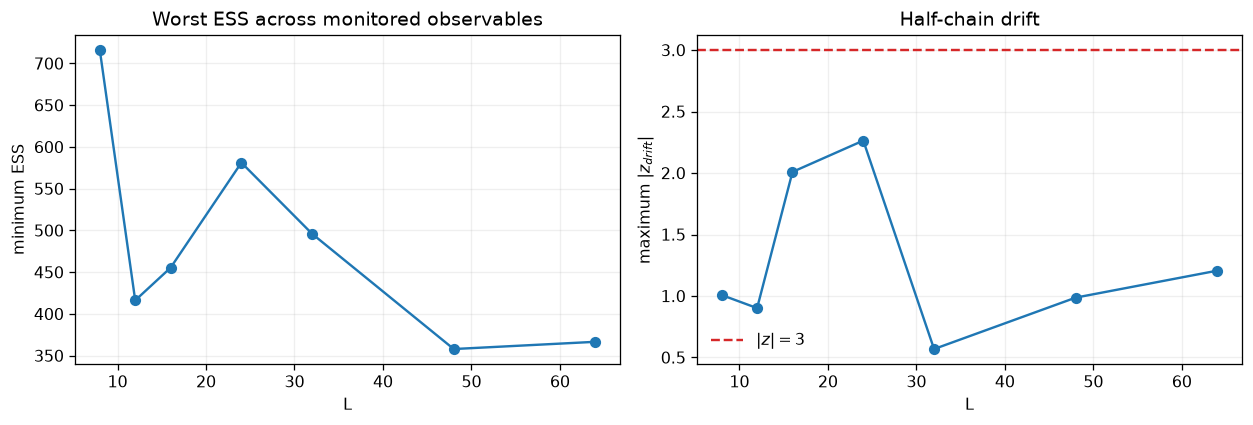

Figure takeaway: all seven ensembles have minimum ESS above 358 and maximum nominal half-chain drift below the |z|=3 warning line. No volume shows an obvious sampling-quality outlier.


In [2]:
ensembles = {}
diagnostics = {}
for index, size in enumerate(SIZES):
    stem = DATA_ROOT / f"phi4_L{size}_k0.340301_lam1"
    with np.load(Path(f"{stem}.npz")) as data:
        fields = np.asarray(data["configurations"], dtype=np.float64)
        assert fields.shape == (4, 250, size, size)
        assert float(data["kappa"]) == KAPPA
        assert float(data["lam"]) == LAM
        assert int(data["seed"]) == 1234 + index
        assert np.isfinite(fields).all()
        ensembles[size] = fields
    diagnostics[size] = json.loads(Path(f"{stem}.json").read_text())

print(" L   shape             seed   acceptance   min ESS   max |drift z|")
for size in SIZES:
    meta = diagnostics[size]
    sampler = meta["sampler"]
    ess = meta["effective_sample_size"]
    drift = meta["half_drift_z_score"]
    print(
        f"{size:>2}   {str(ensembles[size].shape):<17}"
        f" {meta['parameters']['seed']:>4}      {sampler['production_acceptance']:.3f}"
        f"      {min(ess.values()):6.1f}        {max(abs(x) for x in drift.values()):5.2f}"
    )

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(SIZES, [min(diagnostics[L]["effective_sample_size"].values()) for L in SIZES], "o-")
axes[0].set(xlabel="L", ylabel="minimum ESS", title="Worst ESS across monitored observables")
axes[1].plot(SIZES, [max(abs(x) for x in diagnostics[L]["half_drift_z_score"].values()) for L in SIZES], "o-")
axes[1].axhline(3.0, color="tab:red", ls="--", label=r"$|z|=3$")
axes[1].set(xlabel="L", ylabel=r"maximum $|z_{drift}|$", title="Half-chain drift")
axes[1].legend(frameon=False)
plt.tight_layout()
plt.show()
print(
    "Figure takeaway: all seven ensembles have minimum ESS above "
    f"{min(min(diagnostics[L]['effective_sample_size'].values()) for L in SIZES):.0f} "
    "and maximum nominal half-chain drift below the |z|=3 warning line. "
    "No volume shows an obvious sampling-quality outlier."
)


## 2. Kernel structure and volume-independent spectral stability

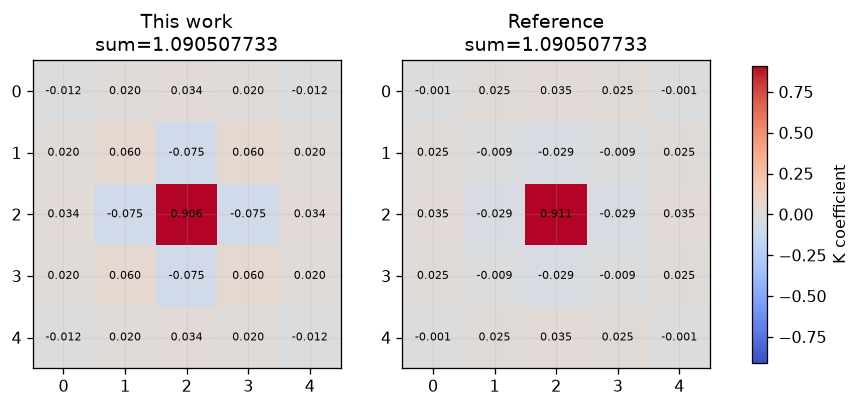

Figure takeaway: the two kernels share the required total normalization but distribute their local weights differently; the largest coefficient difference is 0.0690.
SOS analytic floor: 0.05452538663326289
kernel       min over L    max condition
This work     0.654063       2.1056
Reference     0.707812       1.5448


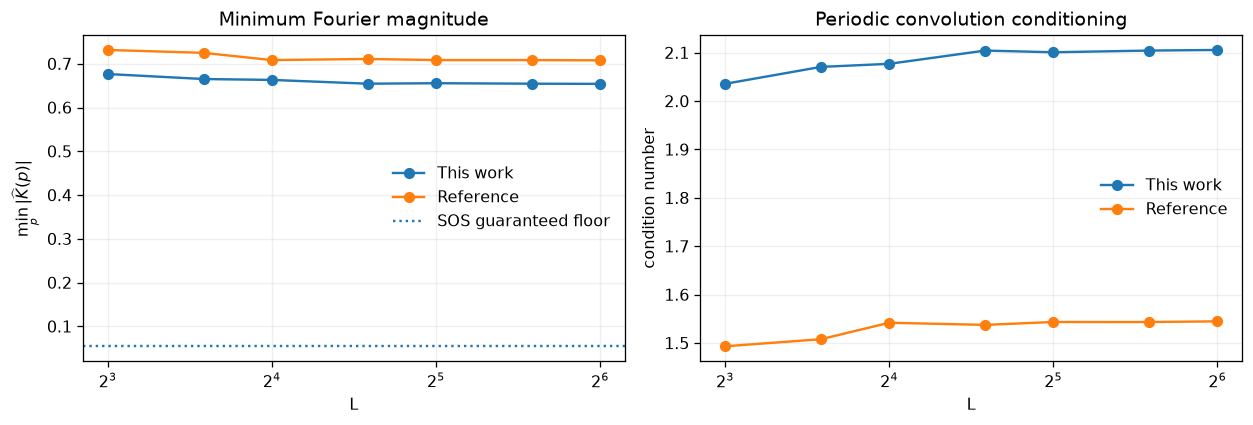

Figure takeaway: both periodic convolutions remain invertible on every tested volume. The reference kernel is better conditioned numerically, while the this-work kernel also carries an analytic positive-spectrum guarantee from its SOS construction.

Agreement of the infrared kernel response
fine L   |K(p_min)| SOS   |K(p_min)| reference   relative difference
    16      1.04918038           1.04230219             0.6599%
    24      1.07172965           1.06846096             0.3059%
    32      1.07986311           1.07798204             0.1745%
    48      1.08575060           1.08490100             0.0783%
    64      1.08782667           1.08734609             0.0442%


In [3]:
current_meta = json.loads(CURRENT_PATH.read_text())
reference_meta = json.loads(REFERENCE_PATH.read_text())
kernels = {
    "This work": np.asarray(current_meta["matrix"], dtype=np.float64),
    "Reference": np.asarray(reference_meta["matrix"], dtype=np.float64),
}
assert current_meta["parameterization"] == "multichannel_sos"
assert current_meta["sos"]["channels"] == 2
assert reference_meta["kappa_f"] == KAPPA == reference_meta["kappa_c"]
for kernel in kernels.values():
    np.testing.assert_allclose(np.sum(kernel), 2.0 ** (ETA / 2.0), rtol=0, atol=1e-12)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.1))
vmax = max(np.max(np.abs(K)) for K in kernels.values())
for axis, (name, kernel) in zip(axes, kernels.items()):
    image = axis.imshow(kernel, cmap="coolwarm", vmin=-vmax, vmax=vmax)
    axis.set_title(f"{name}\nsum={kernel.sum():.9f}")
    for row, column in np.ndindex(kernel.shape):
        axis.text(column, row, f"{kernel[row, column]:.3f}", ha="center", va="center", fontsize=7)
fig.colorbar(image, ax=axes, shrink=0.82, label="K coefficient")
plt.show()
print(
    "Figure takeaway: the two kernels share the required total normalization but distribute "
    f"their local weights differently; the largest coefficient difference is "
    f"{np.max(np.abs(kernels['This work'] - kernels['Reference'])):.4f}."
)

spectra = {name: {L: spectrum_diagnostics(K, L) for L in SIZES} for name, K in kernels.items()}
print("SOS analytic floor:", current_meta["sos"]["guaranteed_spectral_floor"])
print("kernel       min over L    max condition")
for name in kernels:
    print(f"{name:<13} {min(spectra[name][L]['min_abs_K'] for L in SIZES):.6f}       "
          f"{max(spectra[name][L]['condition_number'] for L in SIZES):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for name in kernels:
    axes[0].plot(SIZES, [spectra[name][L]["min_abs_K"] for L in SIZES], "o-", label=name)
    axes[1].plot(SIZES, [spectra[name][L]["condition_number"] for L in SIZES], "o-", label=name)
axes[0].axhline(current_meta["sos"]["guaranteed_spectral_floor"], color="tab:blue", ls=":", label="SOS guaranteed floor")
axes[0].set(xlabel="L", ylabel=r"$\min_p |\widehat K(p)|$", title="Minimum Fourier magnitude")
axes[1].set(xlabel="L", ylabel="condition number", title="Periodic convolution conditioning")
for axis in axes:
    axis.set_xscale("log", base=2)
    axis.legend(frameon=False)
plt.tight_layout()
plt.show()
print(
    "Figure takeaway: both periodic convolutions remain invertible on every tested volume. "
    "The reference kernel is better conditioned numerically, while the this-work kernel "
    "also carries an analytic positive-spectrum guarantee from its SOS construction."
)

print("\nAgreement of the infrared kernel response")
print("fine L   |K(p_min)| SOS   |K(p_min)| reference   relative difference")
for size in (16, 24, 32, 48, 64):
    sos_pmin = abs(kernel_transform(kernels["This work"], size)[1, 0])
    ref_pmin = abs(kernel_transform(kernels["Reference"], size)[1, 0])
    print(f"{size:>6}      {sos_pmin:.8f}           {ref_pmin:.8f}             {abs(sos_pmin-ref_pmin)/ref_pmin:.4%}")


## 3. Multi-volume one-step blocking

For each observable, the notebook reports the standardized mean shift, KS statistic, JS divergence, $W_1/\sigma_{\rm native}$, and width ratio. Aggregate diagnostics are the ten-observable RMS shift, mean KS/JS/normalized-$W_1$, and mean $|\log(\sigma_b/\sigma_c)|$.

Only one-step maps are evaluated here. This isolates volume scaling of a single learned $DK$ transformation and avoids mixing it with error accumulation from repeated applications.


In [4]:
heldout = {L: ensembles[L][3] for L in SIZES}
all_chains = {L: ensembles[L].reshape(-1, L, L) for L in SIZES}


def compare_ensembles(blocked, target):
    blocked_series = kernel_observable_series(blocked, ACTION)
    target_series = kernel_observable_series(target, ACTION)
    metrics = {
        name: distribution_metrics(blocked_series[name], target_series[name])
        for name in KERNEL_OBSERVABLE_NAMES
    }
    return {"blocked": blocked, "target": target, "blocked_series": blocked_series,
            "target_series": target_series, "metrics": metrics}


def aggregate(metrics):
    shifts = np.array([metrics[name]["standardized_mean_shift"] for name in KERNEL_OBSERVABLE_NAMES])
    ks = np.array([metrics[name]["ks_statistic"] for name in KERNEL_OBSERVABLE_NAMES])
    js = np.array([metrics[name]["js_divergence"] for name in KERNEL_OBSERVABLE_NAMES])
    nw1 = np.array([metrics[name]["wasserstein_1"] / metrics[name]["target_std"] for name in KERNEL_OBSERVABLE_NAMES])
    width = np.array([abs(np.log(metrics[name]["std_ratio"])) for name in KERNEL_OBSERVABLE_NAMES])
    return {"RMS shift": np.sqrt(np.mean(shifts**2)), "mean KS": np.mean(ks),
            "mean JS": np.mean(js), "mean normalized W1": np.mean(nw1),
            "mean |log width ratio|": np.mean(width)}


def evaluate_links(fields):
    results = {}
    for fine, coarse in DIRECT_LINKS:
        results[(fine, coarse)] = {
            name: compare_ensembles(block_field(fields[fine], kernel), fields[coarse])
            for name, kernel in kernels.items()
        }
    return results


direct = evaluate_links(heldout)
direct_all = evaluate_links(all_chains)
print("Held-out chain 3: one-step aggregate metrics")
print("link       kernel          RMS shift  mean KS  mean JS  norm W1  width error")
for link in DIRECT_LINKS:
    for name in kernels:
        values = aggregate(direct[link][name]["metrics"])
        print(f"{link[0]:>2}→{link[1]:<2}      {name:<13} {values['RMS shift']:8.4f}  {values['mean KS']:7.4f}  "
              f"{values['mean JS']:7.4f}  {values['mean normalized W1']:7.4f}  {values['mean |log width ratio|']:10.4f}")

print("\nAll four chains (supplement; trained links include training chains)")
print("link       kernel          RMS shift  mean KS  mean JS")
for link in DIRECT_LINKS:
    for name in kernels:
        values = aggregate(direct_all[link][name]["metrics"])
        print(f"{link[0]:>2}→{link[1]:<2}      {name:<13} {values['RMS shift']:8.4f}  {values['mean KS']:7.4f}  {values['mean JS']:7.4f}")

Held-out chain 3: one-step aggregate metrics
link       kernel          RMS shift  mean KS  mean JS  norm W1  width error
64→32      This work       0.2069   0.1056   0.0427   0.2060      0.0451
64→32      Reference       0.1627   0.0928   0.0385   0.1657      0.0453
32→16      This work       0.1381   0.0988   0.0393   0.1501      0.0580
32→16      Reference       0.1923   0.1096   0.0412   0.1864      0.0733
16→8       This work       0.0513   0.0796   0.0343   0.1013      0.0892
16→8       Reference       0.0648   0.0740   0.0344   0.1014      0.0855
48→24      This work       0.0981   0.0788   0.0333   0.1139      0.0658
48→24      Reference       0.1734   0.0980   0.0405   0.1656      0.0746
24→12      This work       0.1261   0.0808   0.0389   0.1401      0.0587
24→12      Reference       0.1116   0.0812   0.0419   0.1369      0.0722

All four chains (supplement; trained links include training chains)
link       kernel          RMS shift  mean KS  mean JS
64→32      This work    

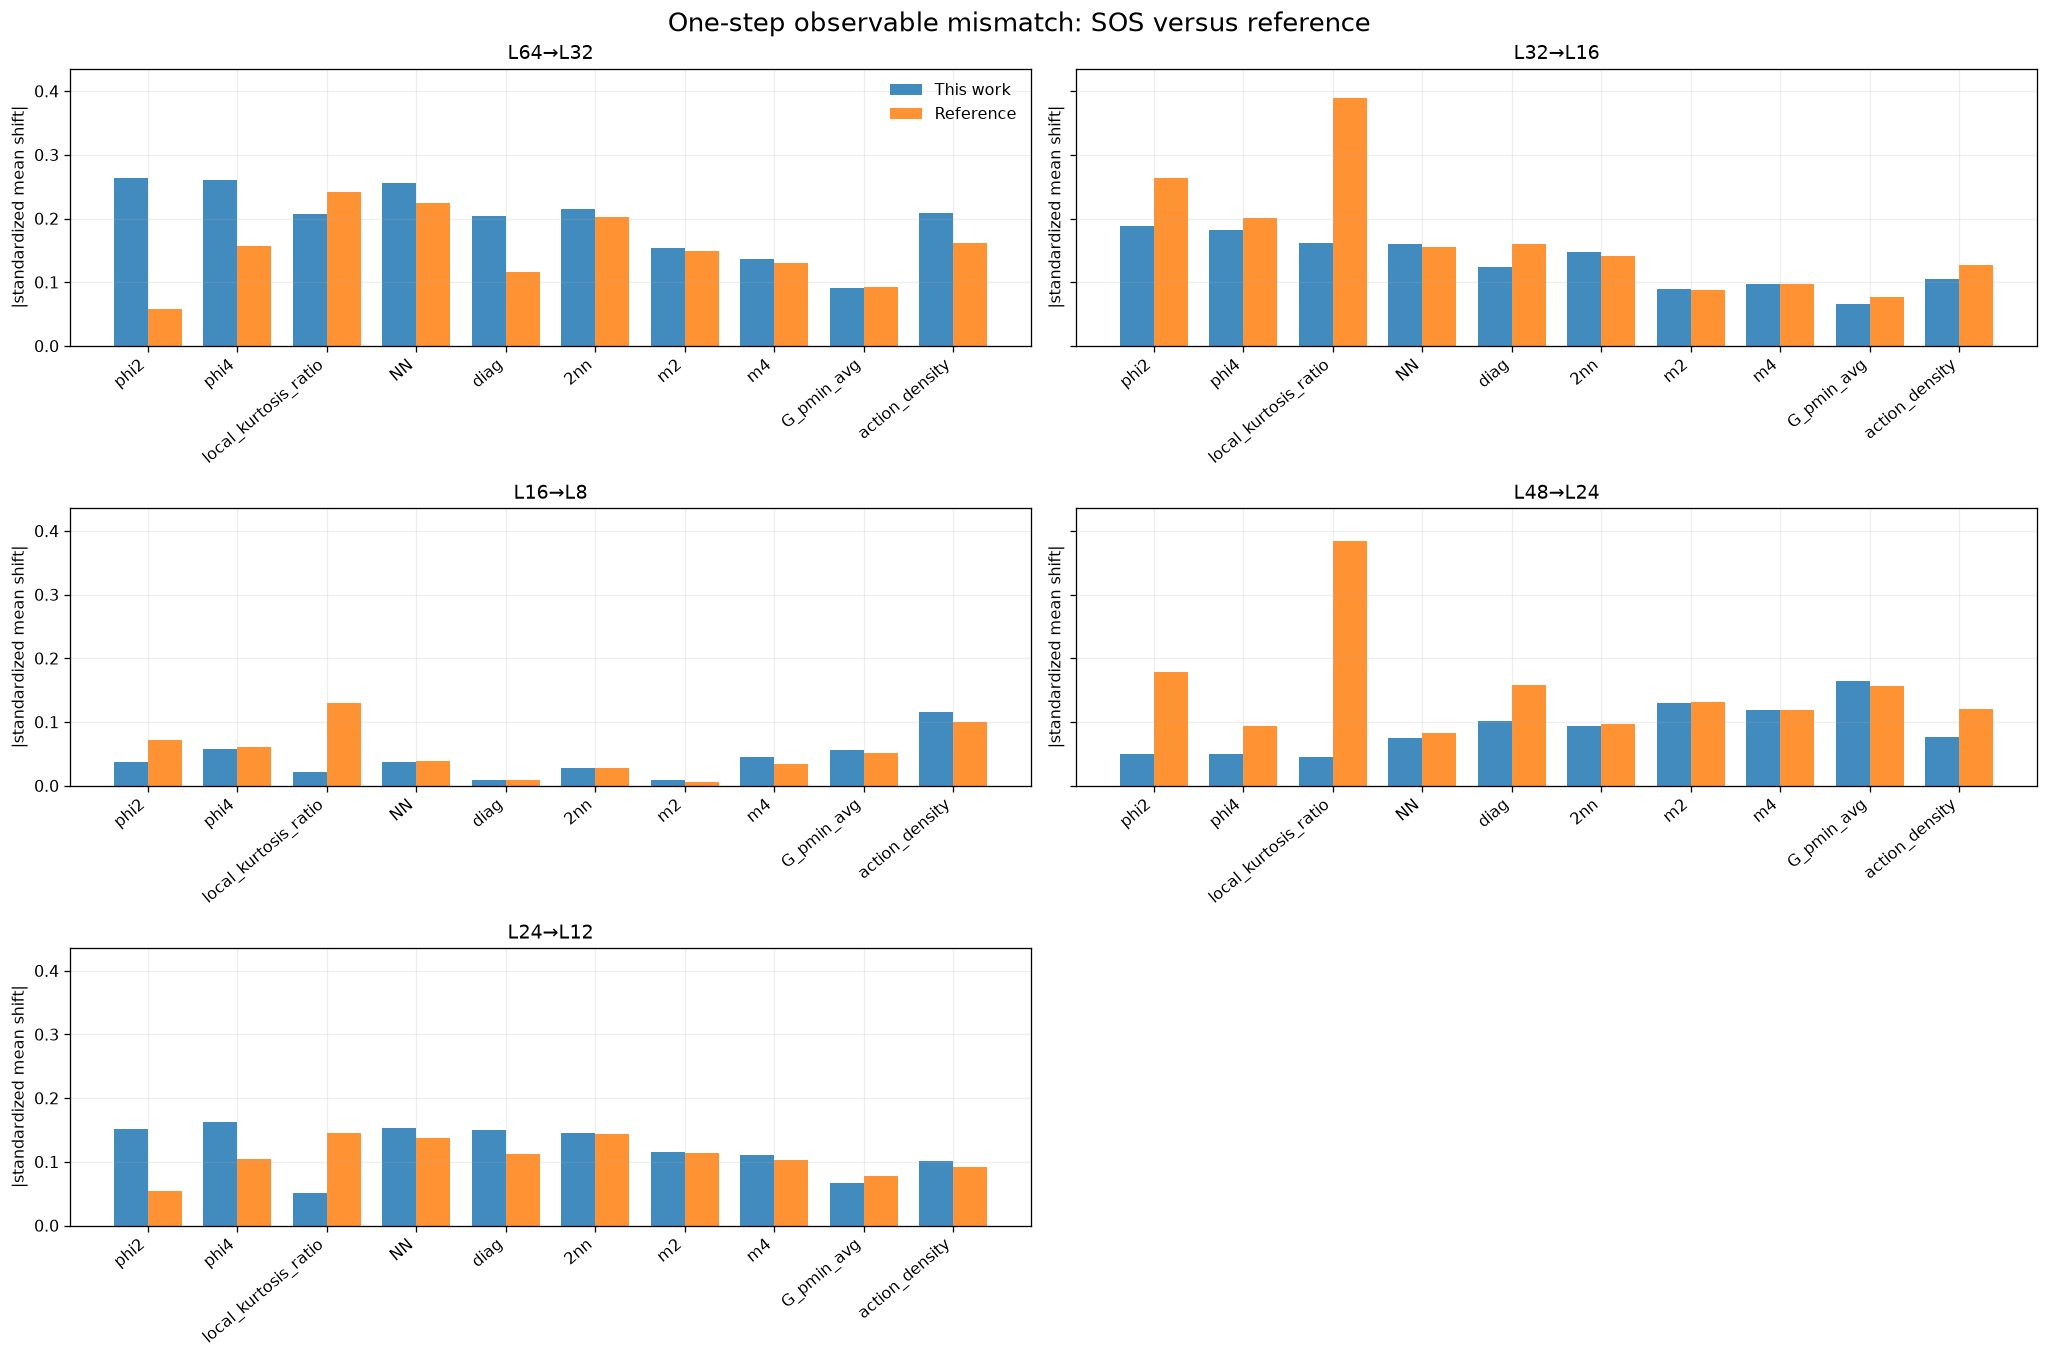

Figure takeaway: the bars expose which observables dominate each one-step mismatch. This work has the lower ten-observable RMS shift on 3 of 5 links; Reference is lower on the remaining 2.


In [5]:
observable_labels = list(KERNEL_OBSERVABLE_NAMES)
x = np.arange(len(observable_labels))
width = 0.38
direct_bar_max = max(
    abs(direct[link][kernel_name]["metrics"][observable]["standardized_mean_shift"])
    for link in DIRECT_LINKS
    for kernel_name in kernels
    for observable in KERNEL_OBSERVABLE_NAMES
)
fig, axes = plt.subplots(3, 2, figsize=(18, 12), sharey=True)
for axis, link in zip(axes.flat, DIRECT_LINKS):
    for offset, color, kernel_name in (
        (-width / 2, "tab:blue", "This work"),
        (width / 2, "tab:orange", "Reference"),
    ):
        values = [
            abs(direct[link][kernel_name]["metrics"][observable]["standardized_mean_shift"])
            for observable in KERNEL_OBSERVABLE_NAMES
        ]
        axis.bar(x + offset, values, width, color=color, alpha=0.85, label=kernel_name)
    axis.set_title(f"L{link[0]}→L{link[1]}")
    axis.set_xticks(x, observable_labels, rotation=40, ha="right")
    axis.set_ylim(0, direct_bar_max * 1.12)
    axis.set_ylabel("|standardized mean shift|")
axes.flat[-1].axis("off")
axes[0, 0].legend(frameon=False)
fig.suptitle("One-step observable mismatch: SOS versus reference", fontsize=16)
fig.tight_layout()
plt.show()
direct_rms_winners = []
for link in DIRECT_LINKS:
    scores = {name: aggregate(direct[link][name]["metrics"])["RMS shift"] for name in kernels}
    direct_rms_winners.append(min(scores, key=scores.get))
print(
    "Figure takeaway: the bars expose which observables dominate each one-step mismatch. "
    f"This work has the lower ten-observable RMS shift on {direct_rms_winners.count('This work')} "
    f"of {len(DIRECT_LINKS)} links; Reference is lower on the remaining "
    f"{direct_rms_winners.count('Reference')}."
)


### One-step mappings: ten-observable distributions on held-out chain 3

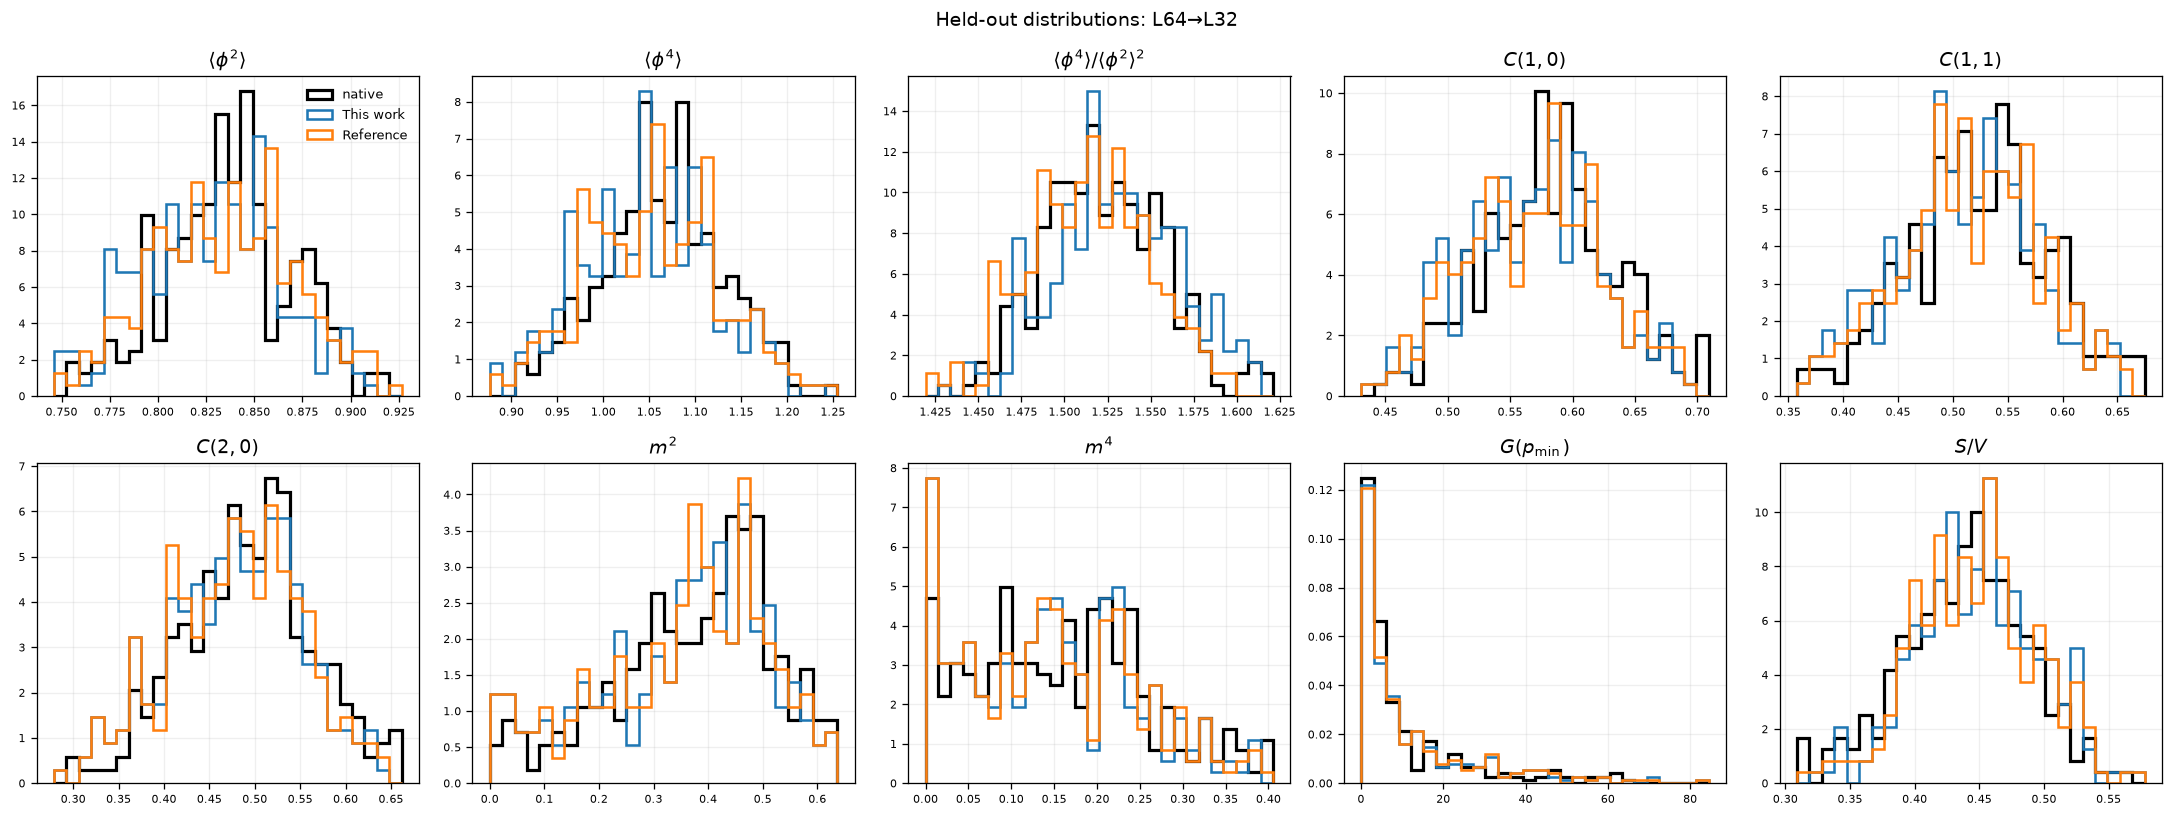

Figure takeaway: Reference has the lower aggregate RMS mean shift for this comparison. This work's largest mean discrepancy is phi2; Reference's largest mean discrepancy is local_kurtosis_ratio. Distribution shapes and widths can still differ even when the mean shift is small.


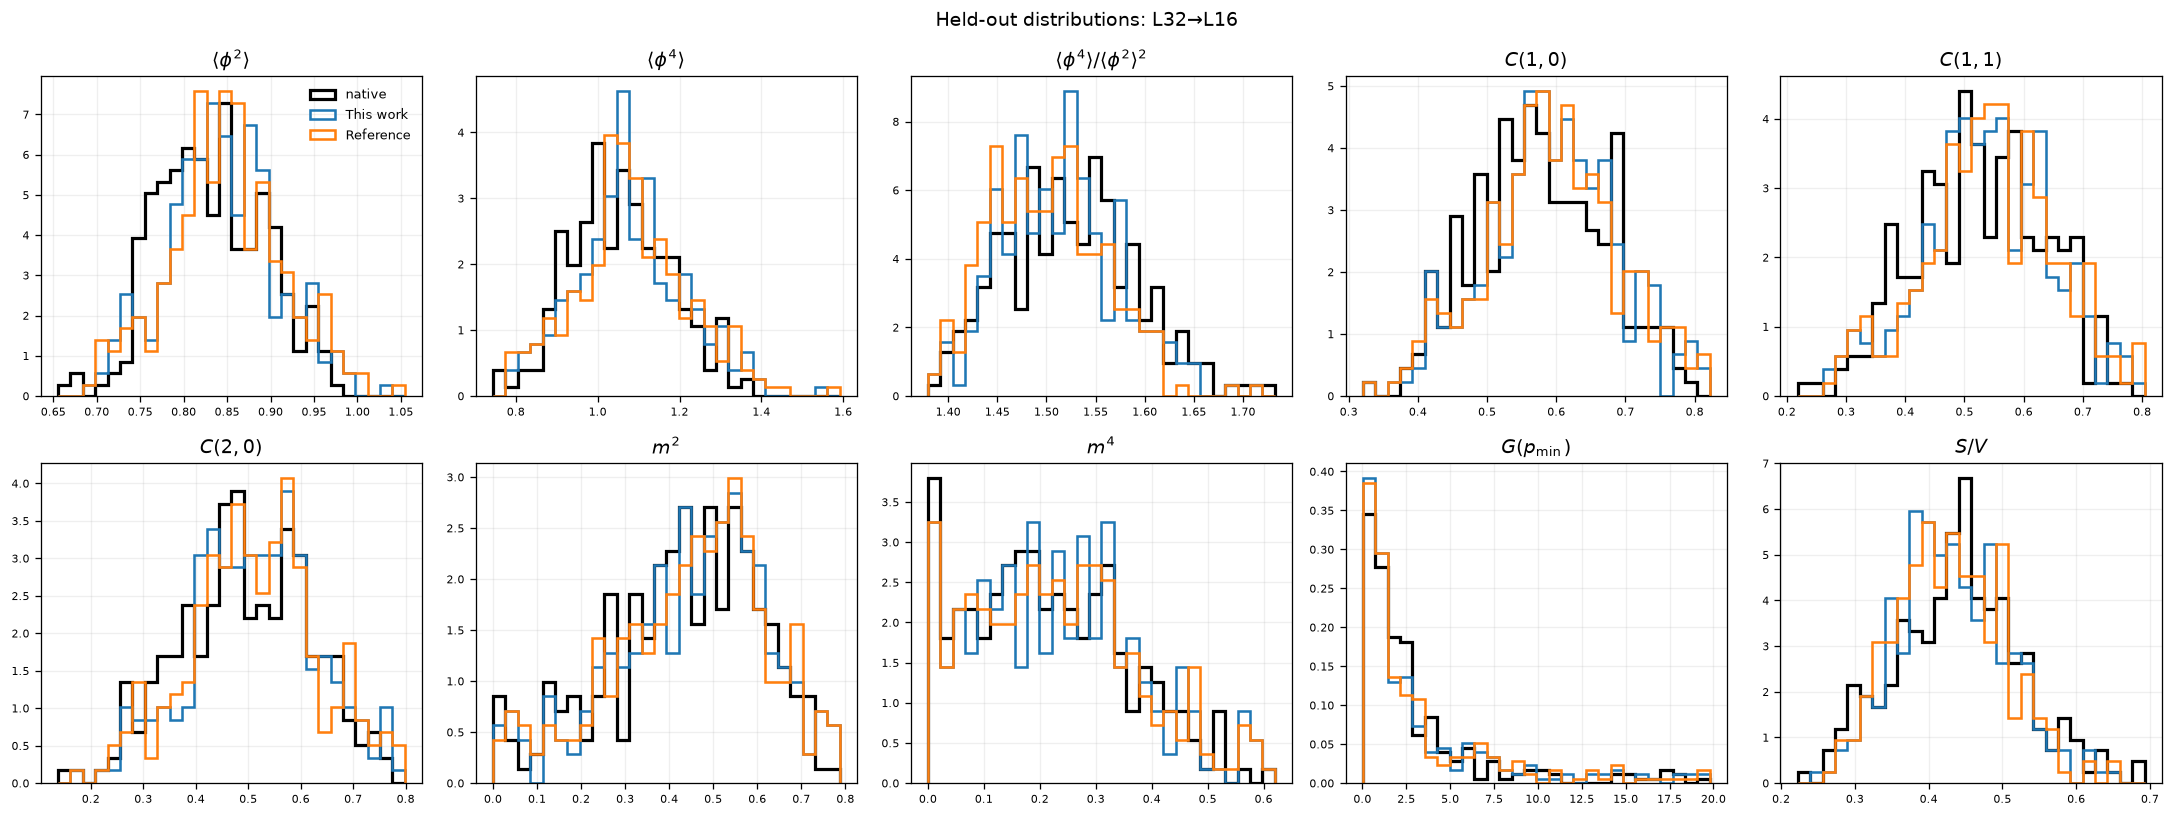

Figure takeaway: This work has the lower aggregate RMS mean shift for this comparison. This work's largest mean discrepancy is phi2; Reference's largest mean discrepancy is local_kurtosis_ratio. Distribution shapes and widths can still differ even when the mean shift is small.


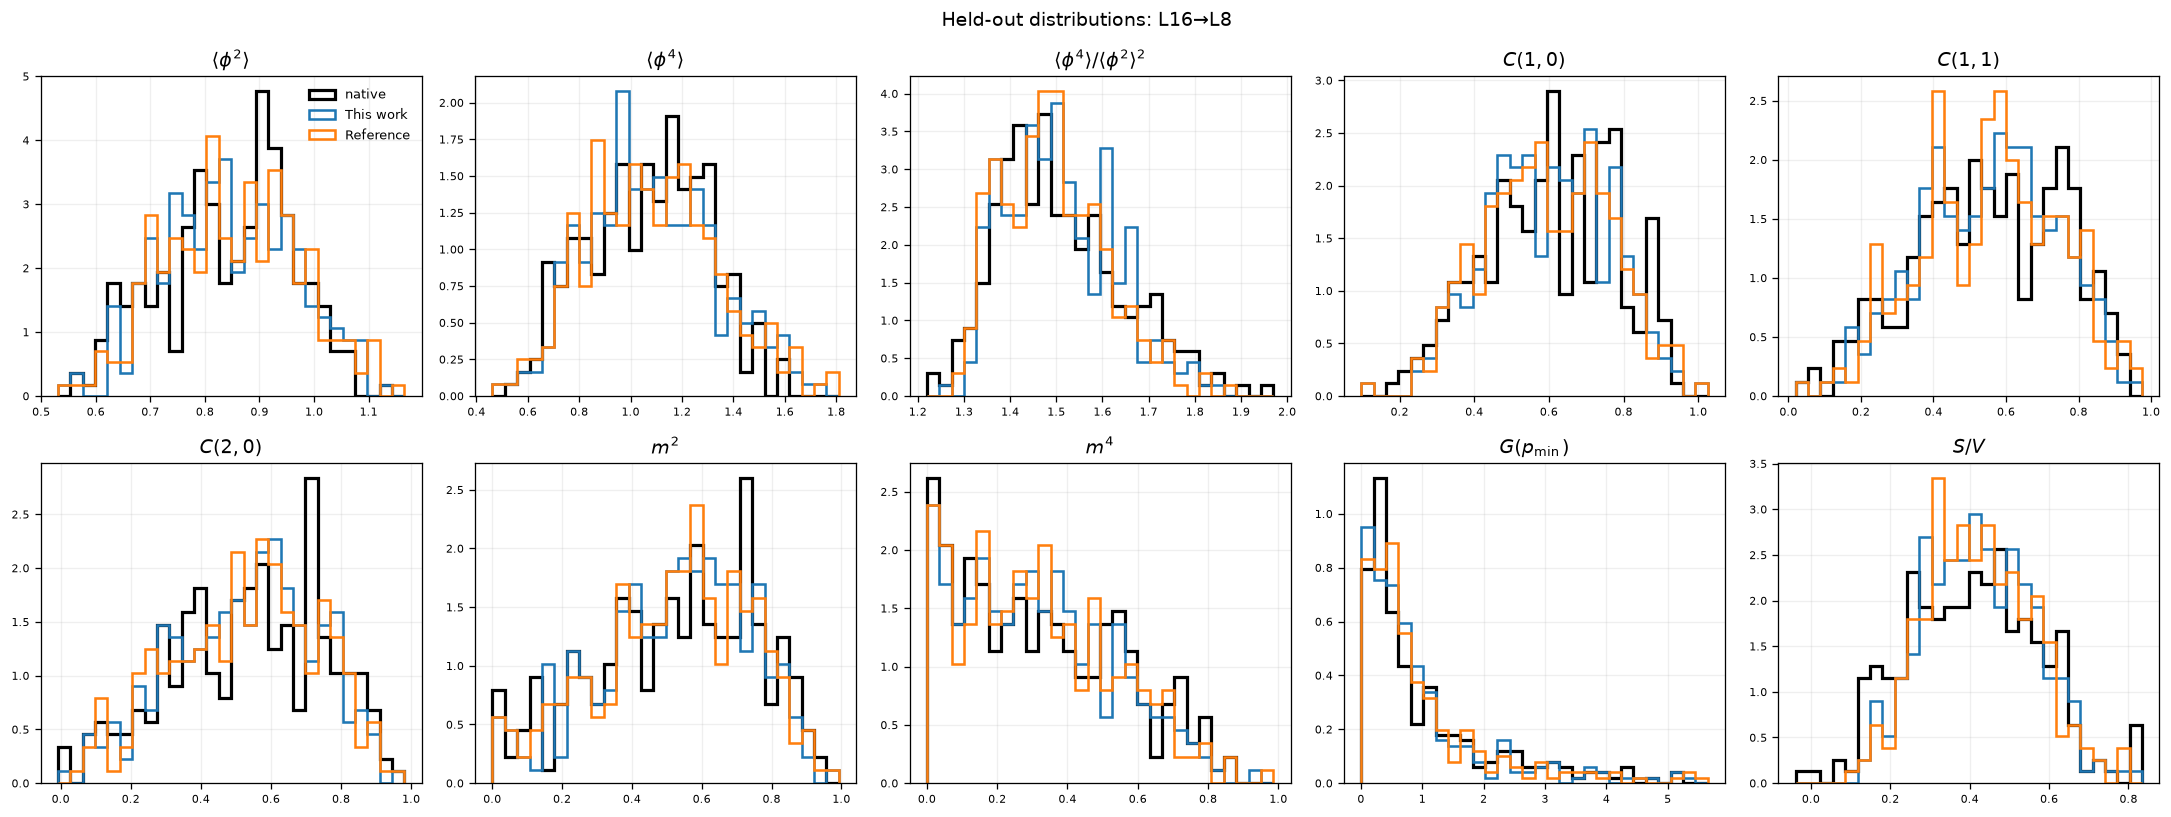

Figure takeaway: This work has the lower aggregate RMS mean shift for this comparison. This work's largest mean discrepancy is action_density; Reference's largest mean discrepancy is local_kurtosis_ratio. Distribution shapes and widths can still differ even when the mean shift is small.


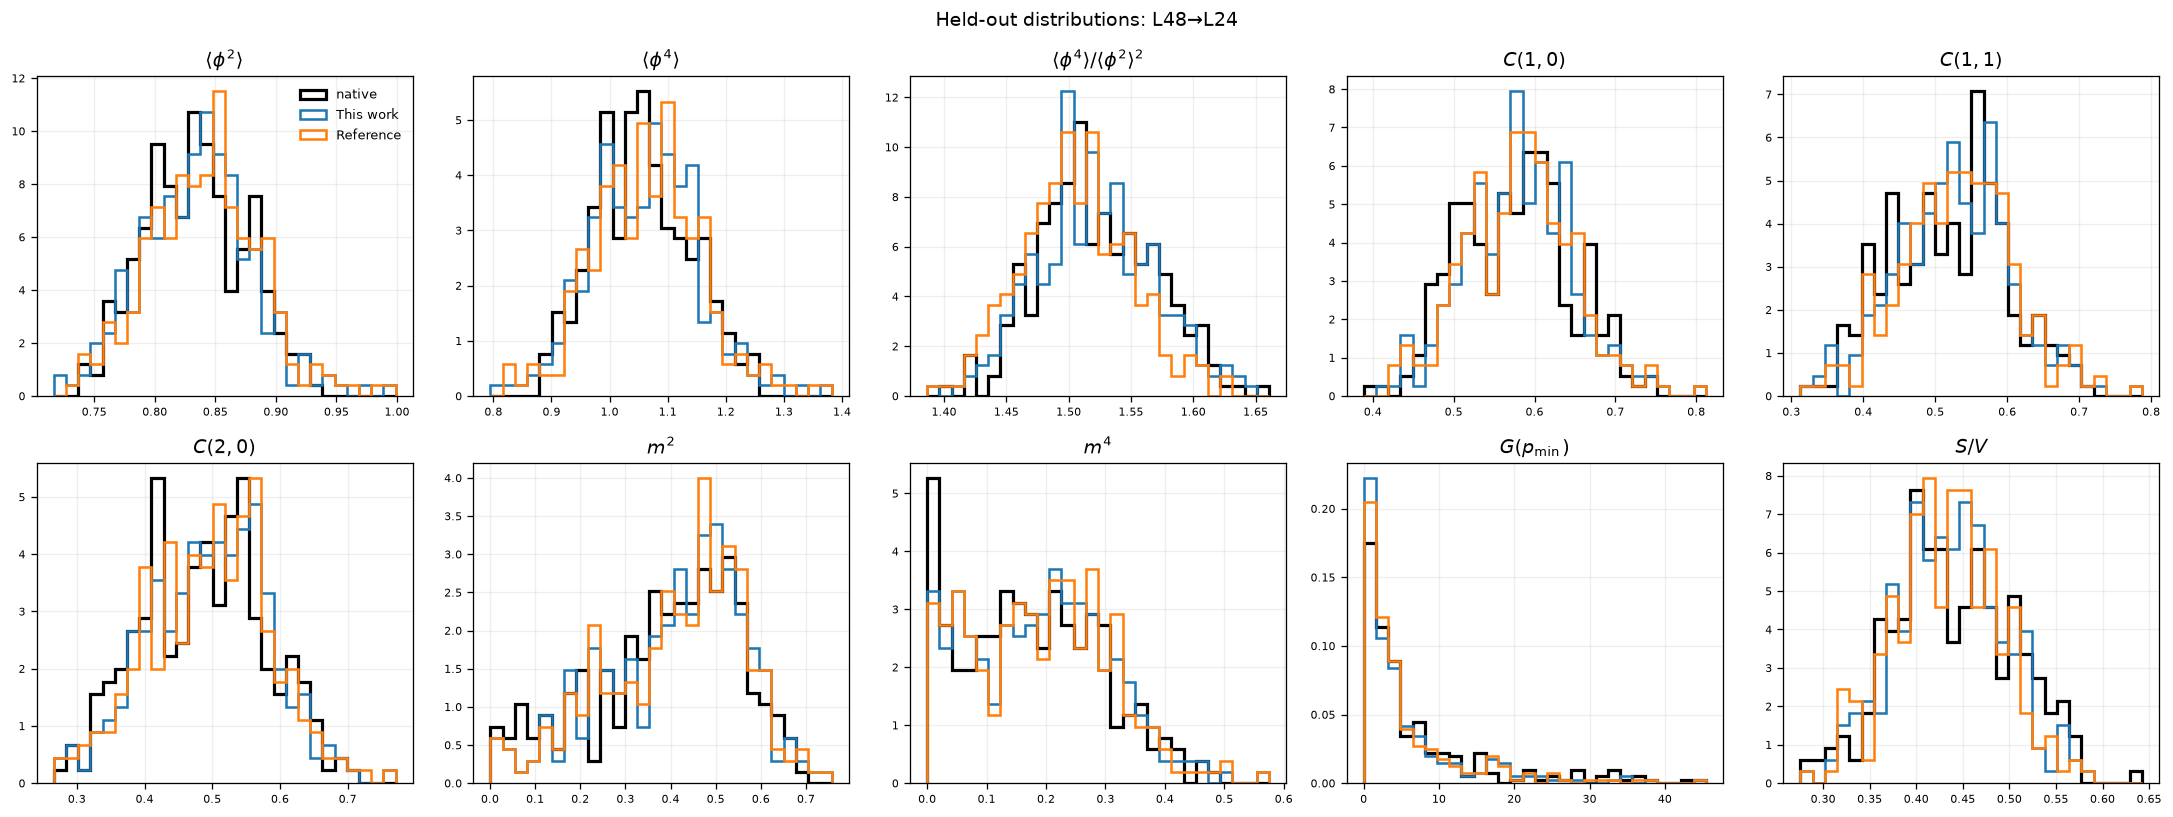

Figure takeaway: This work has the lower aggregate RMS mean shift for this comparison. This work's largest mean discrepancy is G_pmin_avg; Reference's largest mean discrepancy is local_kurtosis_ratio. Distribution shapes and widths can still differ even when the mean shift is small.


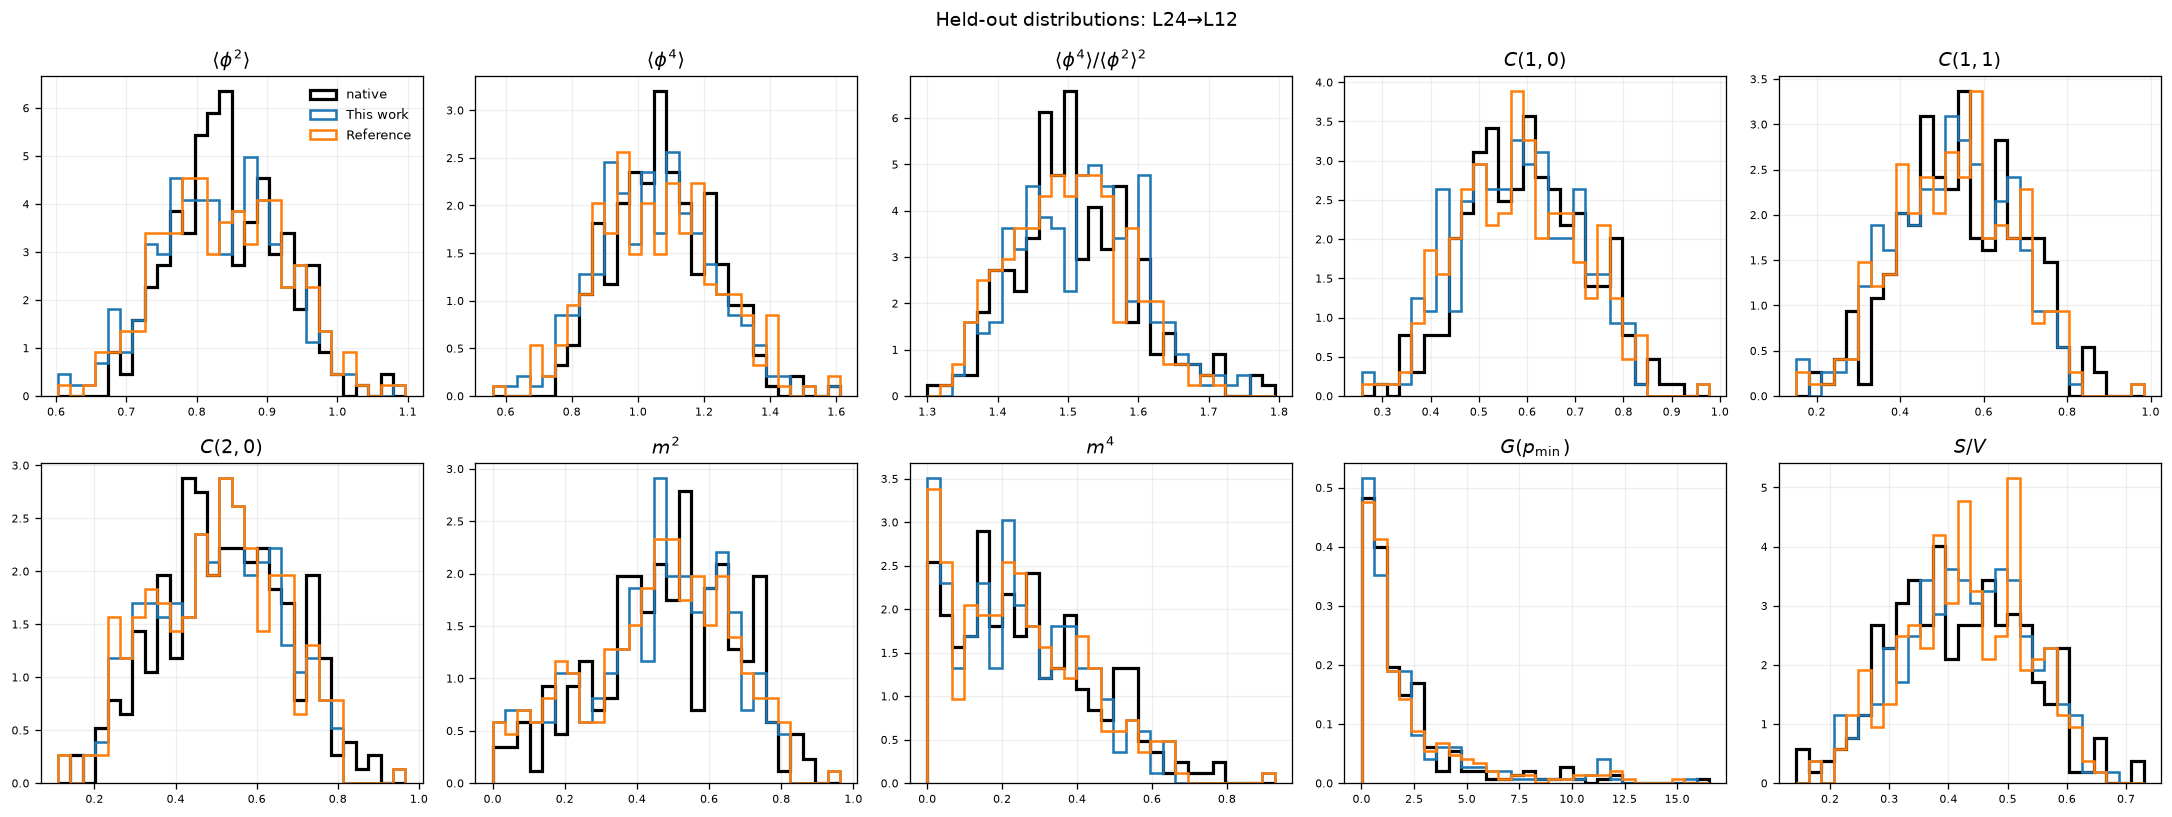

Figure takeaway: Reference has the lower aggregate RMS mean shift for this comparison. This work's largest mean discrepancy is phi4; Reference's largest mean discrepancy is local_kurtosis_ratio. Distribution shapes and widths can still differ even when the mean shift is small.


In [6]:
def plot_histogram_comparison(title, comparisons):
    fig, axes = plt.subplots(2, 5, figsize=(19, 7.2))
    for axis, observable in zip(axes.flat, KERNEL_OBSERVABLE_NAMES):
        target = next(iter(comparisons.values()))["target_series"][observable]
        pooled = np.concatenate([target] + [item["blocked_series"][observable] for item in comparisons.values()])
        bins = np.histogram_bin_edges(pooled, bins=28)
        axis.hist(target, bins=bins, density=True, histtype="step", lw=2.0, color="black", label="native")
        for color, (name, item) in zip(("tab:blue", "tab:orange"), comparisons.items()):
            axis.hist(item["blocked_series"][observable], bins=bins, density=True, histtype="step", lw=1.6, color=color, label=name)
        axis.set_title(KERNEL_OBSERVABLE_TITLES[observable])
        axis.tick_params(labelsize=7)
    axes[0, 0].legend(frameon=False, fontsize=8)
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()
    summaries = {name: aggregate(item["metrics"]) for name, item in comparisons.items()}
    winner = min(summaries, key=lambda name: summaries[name]["RMS shift"])
    largest = {
        name: max(
            KERNEL_OBSERVABLE_NAMES,
            key=lambda observable: abs(item["metrics"][observable]["standardized_mean_shift"]),
        )
        for name, item in comparisons.items()
    }
    print(
        f"Figure takeaway: {winner} has the lower aggregate RMS mean shift for this comparison. "
        + "; ".join(
            f"{name}'s largest mean discrepancy is {largest[name]}"
            for name in comparisons
        )
        + ". Distribution shapes and widths can still differ even when the mean shift is small."
    )

for fine, coarse in DIRECT_LINKS:
    plot_histogram_comparison(f"Held-out distributions: L{fine}→L{coarse}", direct[(fine, coarse)])

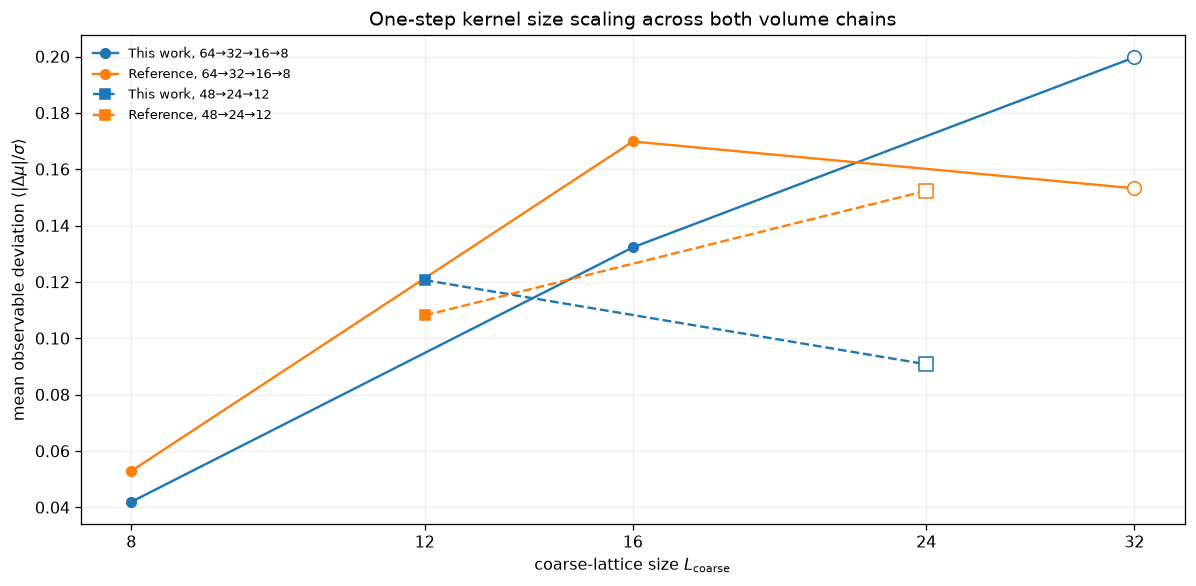

Figure takeaway: filled points are training volume pairs and open points are unseen-volume transfer tests. This work improves three of five links, especially L48→L24, while L64→L32 remains its main scaling limitation. Chain roots L48 and L64 are not plotted as coarse sizes because no L96 or L128 parent ensemble is available for a one-step comparison.


In [7]:
def mean_absolute_standardized_shift(metrics):
    return float(np.mean([
        abs(metrics[observable]["standardized_mean_shift"])
        for observable in KERNEL_OBSERVABLE_NAMES
    ]))


chain_styles = {
    "64→32→16→8": {"targets": (8, 16, 32), "linestyle": "-", "marker": "o"},
    "48→24→12": {"targets": (12, 24), "linestyle": "--", "marker": "s"},
}
training_targets = {8, 12, 16}
kernel_colors = {"This work": "tab:blue", "Reference": "tab:orange"}
fig, axis = plt.subplots(figsize=(10.5, 5.2))
for chain_name, style in chain_styles.items():
    sizes = style["targets"]
    for kernel_name in kernels:
        values = [
            mean_absolute_standardized_shift(direct[(2 * size, size)][kernel_name]["metrics"])
            for size in sizes
        ]
        axis.plot(
            sizes,
            values,
            color=kernel_colors[kernel_name],
            linestyle=style["linestyle"],
            marker=style["marker"],
            label=f"{kernel_name}, {chain_name}",
        )
        for size, value in zip(sizes, values):
            if size not in training_targets:
                axis.scatter(
                    size,
                    value,
                    s=72,
                    facecolors="white",
                    edgecolors=kernel_colors[kernel_name],
                    marker=style["marker"],
                    zorder=4,
                )
axis.set_xscale("log", base=2)
axis.set_xticks((8, 12, 16, 24, 32), ["8", "12", "16", "24", "32"])
axis.set(
    xlabel=r"coarse-lattice size $L_{\rm coarse}$",
    ylabel=r"mean observable deviation $\langle|\Delta\mu|/\sigma\rangle$",
    title="One-step kernel size scaling across both volume chains",
)
axis.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()
print(
    "Figure takeaway: filled points are training volume pairs and open points are unseen-volume " 
    "transfer tests. This work improves three of five links, especially L48→L24, while L64→L32 " 
    "remains its main scaling limitation. Chain roots L48 and L64 are not plotted as coarse sizes " 
    "because no L96 or L128 parent ensemble is available for a one-step comparison."
)


## 4. Finite-size scaling of physical observables

Error bars come from 1,000 circular moving-block bootstrap samples of held-out chain 3, with block length 2. The plots show the Binder cumulant, $\xi/L$, and the critical scaling combination $\chi/L^{2-\eta}$ with $\eta=1/4$.

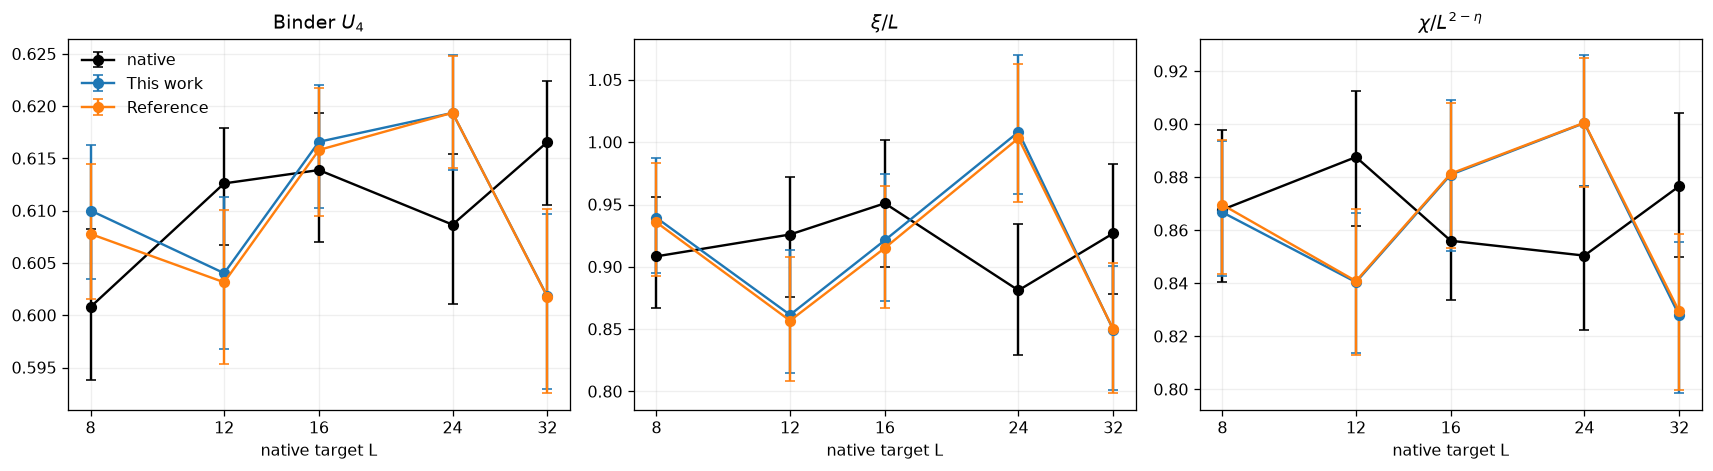

Figure takeaway: This work and Reference nearly overlap for these infrared-dominated quantities, but both show volume-dependent offsets from native. The largest visible offsets occur in xi/L at L24 and in the L12/L32 transfer points.

One-step bootstrap medians
target   ensemble        Binder U4      xi/L      chi/L^(2-eta)
L8      native         0.600793   0.908414   0.867773
L8      This work      0.610019   0.939326   0.866795
L8      Reference      0.607779   0.935657   0.869640
L12     native         0.612612   0.925930   0.887635
L12     This work      0.604022   0.861491   0.840446
L12     Reference      0.603151   0.856815   0.840838
L16     native         0.613889   0.950962   0.856051
L16     This work      0.616591   0.921328   0.881002
L16     Reference      0.615808   0.915126   0.881378
L24     native         0.608666   0.881134   0.850454
L24     This work      0.619357   1.008186   0.900462
L24     Reference      0.619370   1.003156   0.900576
L32     native         0.6

In [8]:
BOOTSTRAP_SAMPLES = 1000
physical_names = ("binder_cumulant", "xi_over_L", "susceptibility")
physical_titles = (r"Binder $U_4$", r"$\xi/L$", r"$\chi/L^{2-\eta}$")
target_sizes = tuple(sorted({coarse for _, coarse in DIRECT_LINKS}))
link_by_target = {coarse: (fine, coarse) for fine, coarse in DIRECT_LINKS}


def bootstrap_summary(fields, size, seed):
    samples = bootstrap_ensemble_observables(fields, samples=BOOTSTRAP_SAMPLES, block_length=2, seed=seed)
    samples["susceptibility"] = samples["susceptibility"] / size ** (2.0 - ETA)
    output = {}
    for name in physical_names:
        finite = samples[name][np.isfinite(samples[name])]
        q16, center, q84 = np.quantile(finite, (0.16, 0.50, 0.84))
        output[name] = (center, center - q16, q84 - center)
    return output

native_bootstrap = {L: bootstrap_summary(heldout[L], L, 3000 + L) for L in target_sizes}
blocked_bootstrap = {name: {} for name in kernels}
for kernel_index, kernel_name in enumerate(kernels):
    for L in target_sizes:
        blocked = direct[link_by_target[L]][kernel_name]["blocked"]
        blocked_bootstrap[kernel_name][L] = bootstrap_summary(blocked, L, 4000 + 100 * kernel_index + L)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for observable, title, axis in zip(physical_names, physical_titles, axes):
    for label, color, source in (
        ("native", "black", native_bootstrap),
        ("This work", "tab:blue", blocked_bootstrap["This work"]),
        ("Reference", "tab:orange", blocked_bootstrap["Reference"]),
    ):
        centers = [source[L][observable][0] for L in target_sizes]
        errors = np.array([[source[L][observable][1] for L in target_sizes], [source[L][observable][2] for L in target_sizes]])
        axis.errorbar(target_sizes, centers, yerr=errors, marker="o", capsize=3, label=label, color=color)
    axis.set_xscale("log", base=2)
    axis.set_xticks(target_sizes, [str(L) for L in target_sizes])
    axis.set(xlabel="native target L", title=title)
axes[0].legend(frameon=False)
plt.tight_layout()
plt.show()
print(
    "Figure takeaway: This work and Reference nearly overlap for these infrared-dominated "
    "quantities, but both show volume-dependent offsets from native. The largest visible offsets "
    "occur in xi/L at L24 and in the L12/L32 transfer points."
)

print("\nOne-step bootstrap medians")
print("target   ensemble        Binder U4      xi/L      chi/L^(2-eta)")
for size in target_sizes:
    for label, source in (
        ("native", native_bootstrap),
        ("This work", blocked_bootstrap["This work"]),
        ("Reference", blocked_bootstrap["Reference"]),
    ):
        print(f"L{size:<5}  {label:<13}  {source[size]['binder_cumulant'][0]:.6f}   "
              f"{source[size]['xi_over_L'][0]:.6f}   {source[size]['susceptibility'][0]:.6f}")


### Why the two blocked curves agree with each other but differ from native ensembles

The agreement between This work and Reference is expected for these infrared-dominated observables. Both kernels have exactly the same normalization, $\widehat K(0)=2^{1/8}$, and nearly identical response at the lowest nonzero momenta. Binder $U_4$, $\xi/L$, and $\chi/L^{2-\eta}$ therefore have little sensitivity to the larger ultraviolet differences between the kernels.

Agreement between the blocked curves does **not** imply agreement with a native ensemble. A finite-support linear convolution followed by decimation generates an effective coarse action with additional couplings. Comparing that blocked ensemble against a native ensemble generated from the unchanged nearest-neighbor bare $\phi^4$ action assumes exact finite-step closure at the fixed point, which neither kernel guarantees. The new objective mildly constrains Binder and $\chi/L^{2-\eta}$ on three training links, but it cannot remove action-closure error; $\xi/L$ is deliberately kept out of training because its ratio estimator is less stable. Finite-volume corrections and 250 correlated held-out configurations add statistical variation.

Consequently, overlap between the two kernel curves mainly shows infrared insensitivity to kernel UV details. Their separation from native measures the remaining finite-step RG, action-closure, and sampling mismatch.


## 5. Summary on matched held-out data


In [9]:
print("One-step winner by ten-observable RMS standardized shift")
for link in DIRECT_LINKS:
    scores = {name: aggregate(direct[link][name]["metrics"])["RMS shift"] for name in kernels}
    winner = min(scores, key=scores.get)
    print(f"L{link[0]}→L{link[1]}: {winner}  " + ", ".join(f"{name}={value:.4f}" for name, value in scores.items()))

print("\nInterpretation guardrails:")
print("- SOS is analytically invertible by construction; the reference spectrum is checked numerically here.")
print("- All performance numbers above were recomputed on identical held-out configurations.")
print("- Filled size-scaling points are trained volume pairs; open points are unseen-volume transfers.")

One-step winner by ten-observable RMS standardized shift
L64→L32: Reference  This work=0.2069, Reference=0.1627
L32→L16: This work  This work=0.1381, Reference=0.1923
L16→L8: This work  This work=0.0513, Reference=0.0648
L48→L24: This work  This work=0.0981, Reference=0.1734
L24→L12: Reference  This work=0.1261, Reference=0.1116

Interpretation guardrails:
- SOS is analytically invertible by construction; the reference spectrum is checked numerically here.
- All performance numbers above were recomputed on identical held-out configurations.
- Filled size-scaling points are trained volume pairs; open points are unseen-volume transfers.


## Reproducibility

- Ensembles: `artifacts/2dphi4/phi4_L{L}_k0.340301_lam1.npz`
- This-work kernel: `artifacts/phi4/kernel/multivolume_sos2_k0.340301/kernel.json`
- Reference kernel: `temp/Inverse_RG/perfect_blocking/perfect_blocking_lam1p0/kernels/final/chosen_kernel.json`
- Primary evaluation split: chain index 3; bootstrap seeds are fixed in the corresponding code cells.
